# Carga de librerías y archivos

In [4]:
# Librerías estándar de Python
from pathlib import Path        # Manejo de rutas de archivos multiplataforma
from math import comb, exp, factorial  # Funciones matemáticas para modelos probabilísticos
import json                     # Lectura de archivos JSON (dataset failbondi)
from scipy.stats import poisson   #Calcular poisson


# Librerías de análisis de datos y visualización
import numpy as np              # Operaciones numéricas y arrays
import pandas as pd             # Manipulación de DataFrames
import matplotlib.pyplot as plt # Generación de gráficos

# Compatibilidad con entornos sin IPython (e.g. scripts locales)
try:
    from IPython.display import display
except ImportError:
    display = print


In [8]:
# Nombres de los archivos requeridos para el análisis
ARCHIVOS_REQUERIDOS = [
    'conectividad_aerea_cabotaje.csv',
    'conectividad_aerea_internacional.csv',
    '202512-informe-ministerio-actualizado-dic-final.csv',
    '202412-informe-ministerio-actualizado-dic-final.csv',
    '202312-informe-ministerio-actualizado-dic.csv',    
    '202604-informe-ministerio.csv',
    'failbondi-2026-05-20-dump.json',
]

def resolver_data_dir():
    """
    Busca automáticamente la carpeta que contiene todos los datasets requeridos.
    Prueba distintas rutas candidatas para funcionar tanto en entornos locales
    como en Google Colab o Drive.
    Retorna el Path a la carpeta encontrada, o lanza FileNotFoundError si no la encuentra.
    """
    candidatos = [
        Path.cwd() / 'datasets',
        Path.cwd(),
        Path.cwd().parent / 'datasets',
        Path.cwd() / '4' / 'datasets',
        Path('/content') / 'datasets',
        Path('/content'),
        Path('/content/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica IV/4') / 'datasets',
        Path('/content/drive/MyDrive/Matematica_IV/4') / 'datasets',
    ]

    for data_dir in candidatos:
        if data_dir.exists() and all((data_dir / archivo).exists() for archivo in ARCHIVOS_REQUERIDOS):
            return data_dir

    raise FileNotFoundError(
        'No se encontraron todos los datasets. '
        'Asegurate de que estén en una carpeta "datasets/" dentro del proyecto.'
    )

# Ruta a la carpeta de datasets (se detecta automáticamente)
DATA_DIR = resolver_data_dir()

# Ruta raíz del proyecto (un nivel arriba de datasets/)
BASE_DIR = DATA_DIR.parent if DATA_DIR.name == 'datasets' else DATA_DIR

# Listado de archivos presentes en la carpeta de datasets
archivos = sorted(p.name for p in DATA_DIR.iterdir())
print('Carpeta de datasets:', DATA_DIR)
print('Datasets encontrados:')
for nombre in archivos:
    print('-', nombre)


Carpeta de datasets: /home/charita/Documentos/UNRN/MATE4/MateIV_Transporte_Publico/datasets
Datasets encontrados:
- 202312-informe-ministerio-actualizado-dic.csv
- 202412-informe-ministerio-actualizado-dic-final.csv
- 202512-informe-ministerio-actualizado-dic-final.csv
- 202604-informe-ministerio.csv
- conectividad_aerea_cabotaje.csv
- conectividad_aerea_internacional.csv
- failbondi-2026-05-20-dump.json


# Carga e inspección de datasets

Contexto del Proyecto: El organismo de planificación turística de San Carlos de Bariloche ha solicitado un informe técnico basado en datos reales de operaciones aeroportuarias. Debido al crecimiento sostenido del turismo, la infraestructura de la ciudad y el aeropuerto se ven exigidos, especialmente en las temporadas de invierno y verano.
Objetivo: El  organismo necesita entender la dinámica de los arribos y partidas para:

    - Optimizar el transporte público y traslados: Ajustar las frecuencias de colectivos y servicios de traslados según el volumen de pasajeros por hora.
    - Prever la saturación de la terminal: Identificar momentos críticos donde la cantidad de vuelos supere la capacidad operativa.
    - Planificación estratégica: Utilizar modelos estadísticos para predecir flujos futuros basados en tendencias históricas.

In [12]:
# Diccionario para traducir nombres de días del inglés al español
DIAS = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes',
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}

def leer_anac(nombre_archivo):
    """
    Carga un archivo CSV de movimientos aeroportuarios de ANAC y lo preprocesa.
    - Usa on_bad_lines='warn' para registrar (sin detener) las filas con errores de formato.
    - Convierte las columnas 'Pasajeros' y 'PAX' a numérico (invalidos → NaN).
    - Parsea 'Fecha UTC' como datetime con formato día/mes/año.
    - Agrega columnas derivadas: año, mes y día de la semana en español.
    """
    df = pd.read_csv(DATA_DIR / nombre_archivo, sep=';', decimal=',', on_bad_lines='warn')
    # Eliminar espacios en los nombres de columnas
    df.columns = df.columns.str.strip()

    # Convertir columnas de pasajeros a numérico (errores se convierten en NaN)
    for columna in ['Pasajeros', 'PAX']:
        df[columna] = pd.to_numeric(df[columna], errors='coerce')

    # Parsear fecha con formato día primero
    df['Fecha UTC'] = pd.to_datetime(
        df['Fecha UTC'],
        dayfirst=True,
        errors='coerce'
    )

    # Columnas temporales derivadas para facilitar los agrupamientos
    df['anio'] = df['Fecha UTC'].dt.year
    df['mes'] = df['Fecha UTC'].dt.month
    df['dia_semana'] = df['Fecha UTC'].dt.day_name().map(DIAS)

    return df

# Cargar los dos archivos ANAC disponibles
anac_2023 = leer_anac ('202312-informe-ministerio-actualizado-dic.csv')
anac_2024 = leer_anac('202412-informe-ministerio-actualizado-dic-final.csv')
anac_2025 = leer_anac('202512-informe-ministerio-actualizado-dic-final.csv')
anac_2026 = leer_anac('202604-informe-ministerio.csv')

# Unificar ambos períodos en un único DataFrame
anac = pd.concat([anac_2023, anac_2024, anac_2025, anac_2026], ignore_index=True)

# Filtrar únicamente los vuelos del aeropuerto de Bariloche (código IATA: BAR)
bariloche = anac[anac['Aeropuerto'] == 'BAR'].copy()


In [13]:
# ── Resumen general del dataset unificado ANAC ──────────────────────────────

print('-' * 100)
print("CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
#Cantidad de filas del dataset
print('Filas cabotaje:', len(anac[anac['Clasificación Vuelo'] == 'Doméstico']))
print('Filas internacional:', len(anac[anac['Clasificación Vuelo'] == 'Internacional']))
print('Filas totales:', len(anac))

# Rango temporal cubierto por el dataset
fecha_inicio = anac['Fecha UTC'].min()
fecha_fin    = anac['Fecha UTC'].max()

print()
print('-' * 100)
print("RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
print("Fecha de inicio del dataset:", fecha_inicio.strftime('%d/%m/%Y'))
print("Fecha fin del dataset:",       fecha_fin.strftime('%d/%m/%Y'))

print()
print('-' * 100)
print("INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC")
print('-' * 100)
print()
# Tipos de datos, cantidad de nulos y uso de memoria por columna
anac.info()


----------------------------------------------------------------------------------------------------
CANTIDAD DE FILAS DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Filas cabotaje: 1540319
Filas internacional: 390539
Filas totales: 1930858

----------------------------------------------------------------------------------------------------
RANGO TEMPORAL DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

Fecha de inicio del dataset: 01/01/2023
Fecha fin del dataset: 30/04/2026

----------------------------------------------------------------------------------------------------
INFORMACIÓN DEL DATASET DE MOVIMIENTOS DE ANAC
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1930858 entries, 0 to 1930857
Data colum

In [14]:
# Visualización de las primeras filas para verificar la carga correcta del dataset
display(anac.head())


,Fecha UTC,Hora UTC,Clase de Vuelo (todos los vuelos),Clasificación Vuelo,Tipo de Movimiento,Aeropuerto,Origen / Destino,Aerolinea Nombre,Aeronave,Pasajeros,PAX,Calidad dato,anio,mes,dia_semana
0,2023-01-01,0:01,Regular,Internacional,Aterrizaje,EZE,LEMD,IBERIA - LINEAS AÉREAS DE ESPAÑA,0,199.0,199.0,DEFINITIVO,2023,1,Domingo
1,2023-01-01,0:10,Regular,Doméstico,Despegue,IGU,EZE,JETSMART AIRLINES S.A.,AIB-A320-232,67.0,33.5,DEFINITIVO,2023,1,Domingo
2,2023-01-01,0:15,Regular,Internacional,Aterrizaje,AER,SBPA,AEROLINEAS ARGENTINAS SA,BO-B-737-76N,36.0,36.0,DEFINITIVO,2023,1,Domingo
3,2023-01-01,0:17,Regular,Doméstico,Aterrizaje,SAL,AER,JETSMART AIRLINES S.A.,AIB-A320-232,168.0,84.0,DEFINITIVO,2023,1,Domingo
4,2023-01-01,0:19,Regular,Doméstico,Aterrizaje,AER,OSA,AEROLINEAS ARGENTINAS SA,EMB-ERJ190100IGW,17.0,8.5,DEFINITIVO,2023,1,Domingo


Exploramos la cantidad de pasajeros que aterrizaron en los diferentes aeropuertos durante el periodo del dataset

In [15]:
# Total de pasajeros (PAX) que aterrizaron en cada aeropuerto durante el período del dataset.
# Se filtra solo por 'Aterrizaje' para no duplicar conteos con las salidas.
pax_por_aeropuerto = (
    anac[anac['Tipo de Movimiento'] == 'Aterrizaje']
        .groupby('Aeropuerto', as_index=False)['PAX']
        .sum()
        .sort_values('PAX', ascending=False)
)

print(pax_por_aeropuerto)


   Aeropuerto         PAX
0         AER  17166943.0
18        EZE  16119650.5
5         CBA   3238111.5
13        DOZ   2539284.0
2         BAR   2132946.0
25        IGU   1387828.5
42        SAL   1316572.5
33        NEU   1013301.0
53        USU    997192.5
16        ECA    775607.0
51        TUC    728409.5
39        ROS    572115.5
8         CRV    464079.5
27        JUJ    438404.5
37        POS    297106.0
6         CHP    260070.5
30        MDP    252232.5
49        TRE    238556.0
3         BCA    199202.0
7         CRR    194119.5
43        SDE    188601.0
44        SIS    175830.5
26        JUA    172480.5
21        GAL    149159.5
14        DRY    146745.0
24        GRA    110889.5
20        FSA     80962.5
17        ESQ     76905.0
4         CAT     75426.5
47        SVO     74426.0
28        LAR     62483.0
52        UIS     53637.0
45        SRA     39647.5
34        OSA     37966.0
36        PAR     37223.0
19        FDO     34194.0
54        VIE     29712.0
48        TR

# Limpieza y preparación de datos


In [24]:
# El archivo 2025 contiene filas con errores de formato que Pandas no puede leer.
# Este bloque cuantifica cuántas filas fueron descartadas durante la carga.

archivo = DATA_DIR / '202512-informe-ministerio-actualizado-dic-final.csv'

# Contar el total de líneas en el archivo (incluyendo encabezado y filas corruptas)
with open(archivo, encoding='utf-8') as f:
    total_lineas = sum(1 for _ in f)

# Cargar solo las filas válidas (on_bad_lines='skip' descarta las corruptas silenciosamente)
df_check = pd.read_csv(
    archivo,
    sep=';',
    decimal=',',
    engine='python',
    on_bad_lines='skip'
)

filas_validas   = len(df_check)
filas_ignoradas = total_lineas - filas_validas  # diferencia = filas corruptas + encabezado

print("Total de líneas:", total_lineas)
print("Filas cargadas:", filas_validas)
print("Filas ignoradas:", filas_ignoradas)


Total de líneas: 597785
Filas cargadas: 597784
Filas ignoradas: 1


In [17]:
# Tabla resumen con dimensiones del dataset unificado
resumen_datasets = pd.DataFrame({
    'dataset':  ['ANAC'],
    'filas':    [len(anac)],
    'columnas': [anac.shape[1]],
})
display(resumen_datasets)

# Conteo de valores nulos en las columnas más relevantes para el análisis
print('Nulos principales en ANAC:')
display(anac[['Fecha UTC', 'Clasificación Vuelo', 'Tipo de Movimiento', 'Pasajeros', 'PAX']].isna().sum())


,dataset,filas,columnas
0,ANAC,1930858,15


Nulos principales en ANAC:


Fecha UTC              0
Clasificación Vuelo    0
Tipo de Movimiento     0
Pasajeros              0
PAX                    0
dtype: int64

# Análisis estadístico descriptivo para Bariloche


Medidas de Tendencia Central: Media y mediana de pasajeros diarios en el aeropuerto de Bariloche.

# ¿Por qué usamos la columna PASAJEROS?


La columna pasajeros refiere a la cantidad de pasajeros por operación individual (despegue/aterrizaje). Para vuelos de cabotaje se registra despegue y aterrizaje. Por ejemplo: en una vuelo Buenos Aires - Bariloche se cuenta al pasajero en el despegue y en el aterrizaje.
Al analizar un Aeropuerto individual se debe tomar el dato de esta columna. Por esta razón para analizar Bariloche vamos a usar la columna Pasajeros.

PAX: 1pax = 1tarjeta de embarque. Usar esta columna al analizar la cantidad de pasajeros cabotaje a nivel total país. Al analizar los pasajeros internacionales es indiferente usar esta columna o la anterior 

# ¿Cuál es la media y la mediana de pasajeros?

In [80]:
# Agrupar por fecha para obtener el total de pasajeros (PAX) por día en Bariloche
pasajeros_diarios = bariloche.groupby('Fecha UTC')['Pasajeros'].sum()

# Medidas de tendencia central
media_pasajeros   = pasajeros_diarios.mean()   # Promedio aritmético
mediana_pasajeros = pasajeros_diarios.median() # Valor central de la distribución

In [78]:
print(
    f"Media: Es el promedio aritmético de pasajeros por día. "
    f"Si la afluencia fuera constante durante todo el año "
    f"el destino debería esperar un movimiento de cercano a "        
    f"{media_pasajeros:.0f} pasajeros por día en el aeropuerto."   
)

Media: Es el promedio aritmético de pasajeros por día. Si la afluencia fuera constante durante todo el año el destino debería esperar un movimiento de cercano a 6806 pasajeros por día en el aeropuerto.


In [45]:
print(
     f"La mediana es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan "
     f"menos de {mediana_pasajeros:.0f} pasajeros y el otro 50% llegan más."
)

La mediana es el valor que divide los datos a la mitad. Indica que el 50% de los días llegan menos de 6658 pasajeros y el otro 50% llegan más.


# ¿Cuál es su desvío estándar?

In [82]:
# Medidas de dispersión sobre los pasajeros diarios en Bariloche
# El desvío estándar indica cuánto se alejan los valores típicos de la media
desvio_estandar    = pasajeros_diarios.std()

# La varianza es el cuadrado del desvío estándar.
varianza_pasajeros = pasajeros_diarios.var()

print(f"--- Análisis de Dispersión para Bariloche ---")
print(f"Desvio estándar: {desvio_estandar:.0f}")
print(f"Varianza:        {varianza_pasajeros:.0f}")


--- Análisis de Dispersión para Bariloche ---
Desvio estándar: 2039
Varianza:        4158212


In [83]:
print(f"El desvío estándar, mide que tan dispersos están los datos respecto a la media que era de "
      f"{media_pasajeros:.0f} pasajeros. El desvio representa un 72 % más sobre la media, porque hay días que pueden llegar "
      f"{desvio_estandar:.0f} pasajeros más. ")


El desvío estándar, mide que tan dispersos están los datos respecto a la media que era de 6806 pasajeros. El desvio representa un 72 % más sobre la media, porque hay días que pueden llegar 2039 pasajeros más. 


# ¿Cuántos pasajeros diarios en promedio llegan por mes a Bariloche?

--- Número promedio de pasajeros diarios por mes ---
    Mes  Media_Pasajeros_Diarios  Desvio_Estandar_Diario
0     1              7537.217742             1163.942771
1     2              6936.663717             1129.278986
2     3              5949.072581              773.562492
3     4              4741.931624              971.850215
4     5              4088.064516              879.351945
5     6              5481.833333             1130.073332
6     7              9841.086022             1813.728628
7     8              9958.301075             1354.574374
8     9              7842.166667             1331.087983
9    10              6404.602151              991.496214
10   11              6154.477778              972.280838
11   12              7253.258065             1077.373304


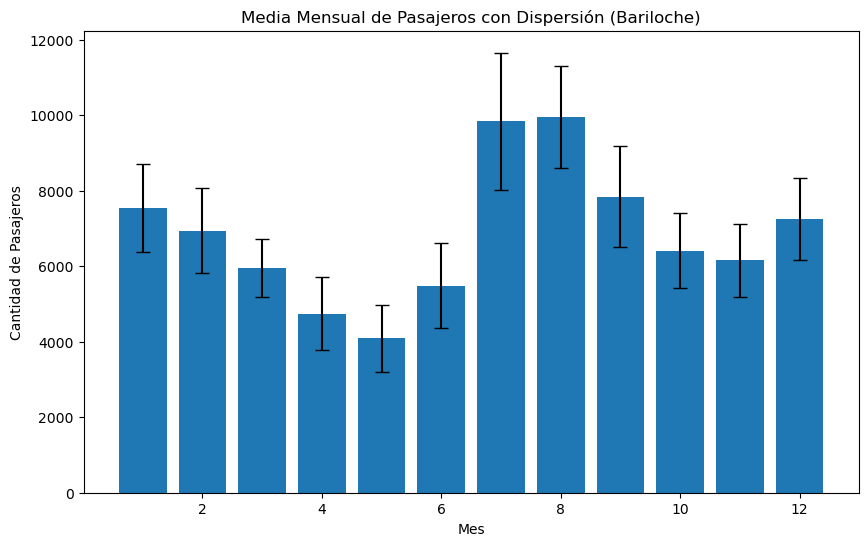

In [57]:
# ── Promedio de pasajeros diarios por mes en Bariloche ───────────────────────

# PASO 1: Sumar todos los pasajeros que llegaron en cada fecha
# Resultado: una fila por día con el total de pasajeros de ese día
pasajeros_por_dia = bariloche.groupby(bariloche['Fecha UTC'].dt.date)['Pasajeros'].sum().reset_index()
pasajeros_por_dia.columns = ['Fecha', 'Total_Pasajeros_Dia']

# PASO 2: Extraer el mes de cada fecha para poder agrupar mensualmente
pasajeros_por_dia['Fecha'] = pd.to_datetime(pasajeros_por_dia['Fecha'])
pasajeros_por_dia['Mes']   = pasajeros_por_dia['Fecha'].dt.month

# PASO 3: Calcular la media y desvío estándar de los totales diarios agrupados por mes
informe_municipal_diario = (
    pasajeros_por_dia
    .groupby('Mes')['Total_Pasajeros_Dia']
    .agg(['mean', 'std'])
    .reset_index()
)
informe_municipal_diario.columns = ['Mes', 'Media_Pasajeros_Diarios', 'Desvio_Estandar_Diario']

print("--- Número promedio de pasajeros diarios por mes ---")
print(informe_municipal_diario)

# Gráfico de barras con barras de error para visualizar la variabilidad mensual
plt.figure(figsize=(10, 6))
plt.bar(
    informe_municipal_diario['Mes'],
    informe_municipal_diario['Media_Pasajeros_Diarios'],
    yerr=informe_municipal_diario['Desvio_Estandar_Diario'],
    capsize=5
)
plt.title('Media Mensual de Pasajeros con Dispersión (Bariloche)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Pasajeros')
plt.show()


In [63]:
mes_max = informe_municipal_diario.loc[
    informe_municipal_diario['Media_Pasajeros_Diarios'].idxmax()
]

Mes con mayor promedio de pasajeros diarios: 8
Promedio: 9958


In [73]:
print(
    f"Agosto es el pico máximo con el mayor promedio diario de pasajeros: "
    f"{mes_max['Media_Pasajeros_Diarios']:.0f}. "
    f"Al ser el desvío estándar superior a 1331, "
    f"es necesario considerar que pueden recibir algunos días más de "
    f"11.000 pasajeros."
)

Agosto es el pico máximo con el mayor promedio diario de pasajeros: 9958. Al ser el desvío estándar superior a 1331, es necesario considerar que pueden recibir algunos días más de  11.000 pasajeros.


# JULIO / AGOSTO vs MAYO: ¿Cómo varía el comportamiento?


--- Comparación horaria: Mayo vs Invierno ---
    Hora  Promedio_Mayo  Promedio_Invierno  Diferencia  Incremento_%
0      0          205.0              308.0       103.0          50.0
1      1          209.0              259.0        51.0          24.0
2      2          200.0              220.0        20.0          10.0
3      3          138.0              233.0        95.0          69.0
4      4          147.0              162.0        15.0          10.0
5      5          157.0              177.0        20.0          13.0
6      6          158.0              184.0        26.0          16.0
7      7          160.0              168.0         7.0           5.0
8      8           94.0              143.0        50.0          53.0
9      9          148.0              189.0        42.0          28.0
10    10          237.0              280.0        43.0          18.0
11    11          209.0              278.0        69.0          33.0
12    12          197.0              312.0       115.0  

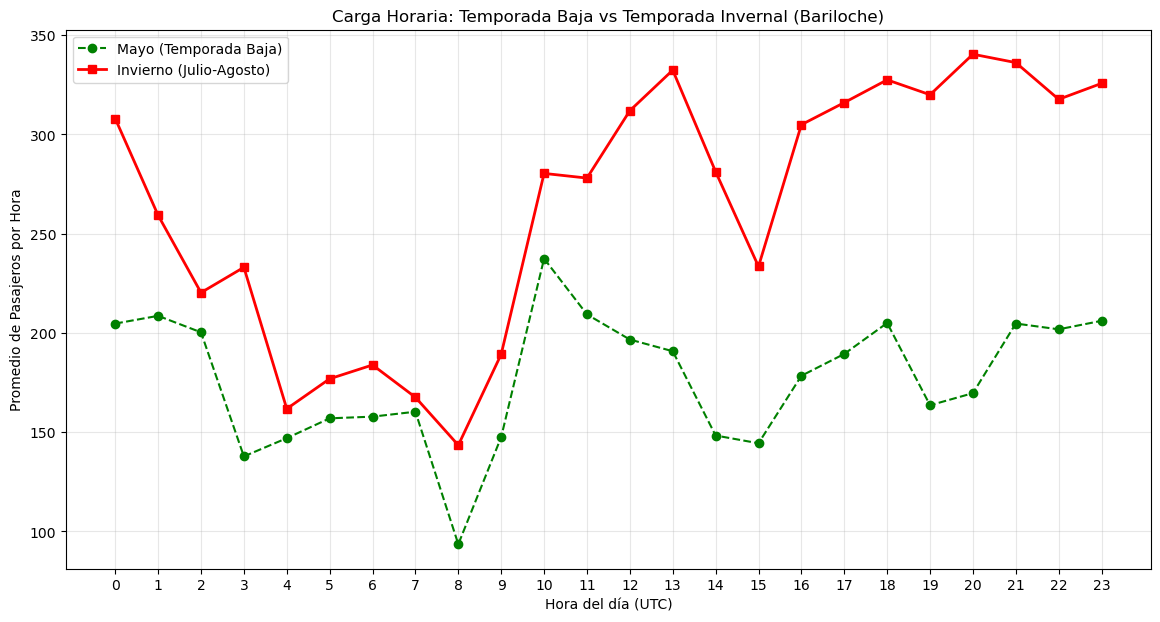

In [90]:
# ── Análisis de carga horaria: temporada alta (agosto) vs. baja (mayo) ────────
# PASO 1: Extraer la hora
anac['hora'] = pd.to_datetime(anac['Hora UTC'], format='%H:%M').dt.hour

# PASO 2: Filtros
filtro_base = (
    (anac['Tipo de Movimiento'] == 'Aterrizaje') &
    (anac['Aeropuerto'] == 'BAR')
)

df_mayo = anac.loc[
    filtro_base &
    (anac['mes'] == 5)
]

df_invierno = anac.loc[
    filtro_base &
    (anac['mes'].isin([7, 8]))
]

def obtener_promedio_horario(df):
    pax_dia_hora = (
        df.groupby(['Fecha UTC', 'hora'])['Pasajeros']
        .sum()
        .reset_index()
    )

    return (
        pax_dia_hora
        .groupby('hora')['Pasajeros']
        .mean()
        .reset_index()
    )

promedio_mayo = obtener_promedio_horario(df_mayo)
promedio_invierno = obtener_promedio_horario(df_invierno)

# TABLA COMPARATIVA
tabla_comparativa = (
    promedio_mayo
    .merge(
        promedio_invierno,
        on='hora',
        suffixes=('_Mayo', '_Invierno')
    )
)

tabla_comparativa.columns = [
    'Hora',
    'Promedio_Mayo',
    'Promedio_Invierno'
]

tabla_comparativa['Diferencia'] = (
    tabla_comparativa['Promedio_Invierno']
    - tabla_comparativa['Promedio_Mayo']
)

tabla_comparativa['Incremento_%'] = (
    tabla_comparativa['Diferencia']
    / tabla_comparativa['Promedio_Mayo']
    * 100
)

print("\n--- Comparación horaria: Mayo vs Invierno ---")
print(tabla_comparativa.round(0))

# GRÁFICO
plt.figure(figsize=(14, 7))

plt.plot(
    promedio_mayo['hora'],
    promedio_mayo['Pasajeros'],
    label='Mayo (Temporada Baja)',
    color='green',
    marker='o',
    linestyle='--'
)

plt.plot(
    promedio_invierno['hora'],
    promedio_invierno['Pasajeros'],
    label='Invierno (Julio-Agosto)',
    color='red',
    marker='s',
    linewidth=2
)

plt.xticks(range(24))
plt.xlabel('Hora del día (UTC)')
plt.ylabel('Promedio de Pasajeros por Hora')
plt.title('Carga Horaria: Temporada Baja vs Temporada Invernal (Bariloche)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Durante la temporada invernal (julio-agosto), el aeropuerto recibe aproximadamente entre 300 y 340 pasajeros por hora en los momentos de mayor demanda. Las franjas más exigentes se concentran entre las 12:00 y las 23:00 UTC, alcanzando un máximo de 340 pasajeros promedio por hora a las 20:00 UTC. En comparación con mayo, el incremento de pasajeros es especialmente significativo durante la tarde y la noche, llegando incluso a duplicar la demanda en algunas franjas horarias. El caso más destacado se observa a las 20:00 UTC, donde el volumen aumenta un 101% respecto de la temporada baja. Esta situación justifica reforzar la disponibilidad de transporte terrestre, servicios turísticos, personal operativo y capacidad de atención durante gran parte de la jornada.

Las franjas de menor actividad se concentran entre las 04:00 y las 08:00 UTC, registrándose el mínimo absoluto a las 08:00 UTC con un promedio de 143 pasajeros durante la temporada invernal. Sin embargo, incluso en esta hora de menor demanda, el volumen de pasajeros supera en un 53% al observado en mayo, lo que evidencia que la actividad aeroportuaria se mantiene elevada durante todo el período turístico.


# En agosto, ¿Qué día de la semana recibe más pasajeros?

  dia_semana  Pasajeros
0      Lunes     4739.0
1     Martes     4698.0
2  Miércoles     4572.0
3     Jueves     5060.0
4    Viernes     4981.0
5     Sábado     5938.0
6    Domingo     4939.0


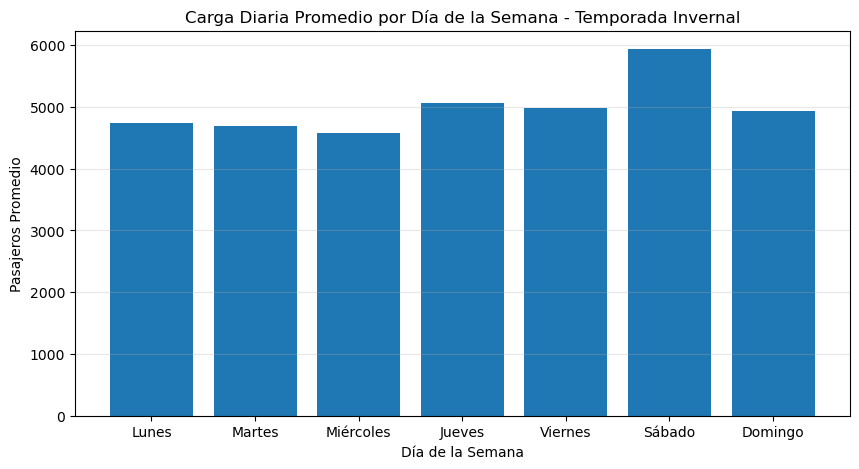

In [91]:
# ── Distribución semanal de pasajeros en Bariloche durante Agosto ─────────────
# PASO 1: Sumar pasajeros por fecha
pax_diarios_invierno = (
    df_invierno
    .groupby('Fecha UTC')['Pasajeros']
    .sum()
    .reset_index()
)

# PASO 2: Obtener día de la semana
pax_diarios_invierno['dia_semana'] = (
    pax_diarios_invierno['Fecha UTC']
    .dt.day_name()
)

# PASO 3: Orden de días
orden_dias = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# PASO 4: Promedio por día de la semana
promedio_invierno_semanal = (
    pax_diarios_invierno
    .groupby('dia_semana')['Pasajeros']
    .mean()
    .reindex(orden_dias)
    .reset_index()
)

# PASO 5: Traducir
promedio_invierno_semanal['dia_semana'] = (
    promedio_invierno_semanal['dia_semana']
    .map(DIAS)
)

print(promedio_invierno_semanal.round(0))

plt.figure(figsize=(10, 5))

plt.bar(
    promedio_invierno_semanal['dia_semana'],
    promedio_invierno_semanal['Pasajeros']
)

plt.title('Carga Diaria Promedio por Día de la Semana - Temporada Invernal')
plt.ylabel('Pasajeros Promedio')
plt.xlabel('Día de la Semana')
plt.grid(axis='y', alpha=0.3)

plt.show()

El análisis de la distribución semanal durante la temporada invernal evidencia una marcada concentración de pasajeros hacia el fin de semana. Los sábados constituyen el día de mayor demanda, con un promedio de 5.938 pasajeros, mientras que los miércoles registran el menor volumen, con 4.572 pasajeros. La diferencia entre ambos extremos alcanza aproximadamente 1.366 pasajeros diarios, lo que representa una variación cercana al 30%. Asimismo, se observa un incremento gradual de la actividad a partir del jueves, alcanzando su máximo durante el sábado. 

# ¿Qué probabilidades pueden estimarse con modelos binomial y Poisson?

- **Binomial:** ¿Cuál es la probabilidad de que, al seleccionar 10 movimientos al azar durante la temporada invernal, al menos 3 transporten más de 174 pasajeros?
- **Poisson:** ¿Cuál es la probabilidad de que, durante un día de la temporada invernal, se registren más de 10 movimientos con más de 174 pasajeros?

In [102]:
# ── Modelo Binomial: movimientos de muy alta demanda durante el invierno ──────

# PASO 1: Definir el umbral de "muy alta demanda" utilizando el percentil 75.
# Esto significa que solo el 25% de los movimientos tienen más pasajeros
# que este valor.
umbral_alto = df_invierno['Pasajeros'].quantile(0.75)

print(f"Umbral de muy alta demanda: {umbral_alto:.0f} pasajeros")

# PASO 2: Calcular la probabilidad de que un movimiento supere dicho umbral.
# Esta será la probabilidad de éxito (p) del modelo binomial.
p_alta_demanda = (
    df_invierno['Pasajeros'] > umbral_alto
).mean()

print(f"p = {p_alta_demanda:.3f}")

# PASO 3: Definir los parámetros del experimento.
# Se seleccionan 10 movimientos al azar y se desea conocer la probabilidad
# de que al menos 3 sean de muy alta demanda.
n = 10
k_min = 3

# PASO 4: Calcular P(X ≥ 3) utilizando la distribución binomial.
# Se suman las probabilidades de obtener 3, 4, ..., 10 movimientos
# de muy alta demanda.
prob_binomial_al_menos_3 = sum(
    comb(n, k) * (p_alta_demanda ** k) * ((1 - p_alta_demanda) ** (n - k))
    for k in range(k_min, n + 1)
)

# PASO 5: Mostrar resultados.
print(
    f"Probabilidad de que al menos 3 de 10 movimientos "
    f"sean de muy alta demanda "
)

print(
    f"Porcentaje: {prob_binomial_al_menos_3 * 100:.2f}%"
)

Umbral de muy alta demanda: 174 pasajeros
p = 0.244
Probabilidad de que al menos 3 de 10 movimientos sean de muy alta demanda 
Porcentaje: 45.75%


Se definió como movimiento de muy alta demanda a aquel que transporta más de 174 pasajeros, valor correspondiente al percentil 75 de la distribución de pasajeros durante la temporada invernal. Esto implica que aproximadamente el 24,4% de los movimientos observados supera dicho umbral.

Mediante un modelo binomial se estimó la probabilidad de que, al seleccionar 10 movimientos al azar durante el invierno, al menos 3 correspondan a esta categoría. El resultado obtenido fue del 45,75%, lo que indica que la presencia de movimientos de muy alta demanda es relativamente frecuente durante la temporada turística.

Desde una perspectiva operativa, este resultado sugiere que es habitual que varios movimientos de elevada ocupación coincidan en períodos cortos de tiempo, por lo que la infraestructura aeroportuaria y los servicios asociados deben contar con capacidad suficiente para absorber incrementos significativos de pasajeros sin afectar la calidad del servicio.

In [108]:
# ── Modelo de Poisson: movimientos de muy alta demanda por día ───────────────

# PASO 1: Definir el umbral de muy alta demanda.
# Se utiliza el percentil 75 de pasajeros de la temporada invernal.
umbral_alto = df_invierno['Pasajeros'].quantile(0.75)

# PASO 2: Identificar los movimientos que superan dicho umbral.
movimientos_altos = df_invierno[
    df_invierno['Pasajeros'] > umbral_alto
]

# PASO 3: Contar cuántos movimientos de muy alta demanda ocurren cada día.
altos_por_dia = (
    movimientos_altos
    .groupby('Fecha UTC')
    .size()
    .reset_index(name='Movimientos_Alta_Demanda')
)

# PASO 4: Calcular λ (lambda), es decir,
# el número promedio diario de movimientos de muy alta demanda.
lambda_poisson = altos_por_dia['Movimientos_Alta_Demanda'].mean()

print(f"Umbral de muy alta demanda: {umbral_alto:.0f} pasajeros")
print(
    f"Promedio diario de movimientos de muy alta demanda (λ): "
    f"{lambda_poisson:.2f}"
)

# PASO 5: Calcular la probabilidad de observar más de 10 movimientos
# de muy alta demanda en un día cualquiera de la temporada invernal.
x = 10

prob_mas_de_10 = 1 - poisson.cdf(x, lambda_poisson)

print(
    f"\nProbabilidad de que un día registre más de {x} "
    f"movimientos de muy alta demanda:"
)
print(f"{prob_mas_de_10:.4f}")
print(f"{prob_mas_de_10 * 100:.2f}%")

Umbral de muy alta demanda: 174 pasajeros
Promedio diario de movimientos de muy alta demanda (λ): 8.27

Probabilidad de que un día registre más de 10 movimientos de muy alta demanda:
0.2122
21.22%


El análisis mediante un modelo de Poisson indica que durante la temporada invernal se producen, en promedio, 8,27 movimientos diarios de muy alta demanda, definidos como aquellos que transportan más de 174 pasajeros. A partir de este promedio, se estimó una probabilidad del 21,22% de que en un día cualquiera se registren más de 10 movimientos de esta categoría.

# Conclusión

# Bibliografía

- Administración Nacional de Aviación Civil (ANAC). Datos de aterrizajes y despegues publicados en datos.gob.ar.
